In [19]:
from google.colab import files
uploaded = files.upload()

Saving autism_screening.csv to autism_screening (2).csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

/tmp/ipykernel_12299/4186911056.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


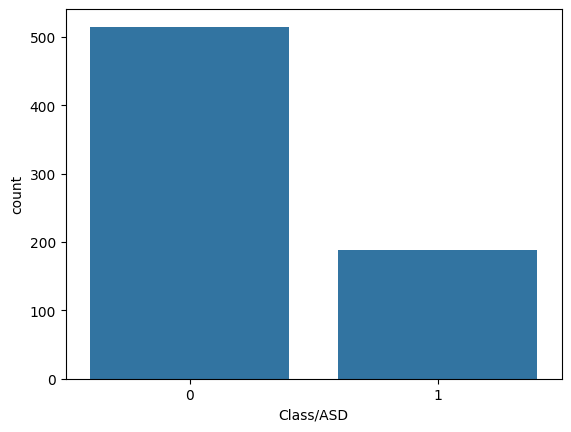

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('autism_screening.csv')
df.head()
df.shape

df.columns
df.info()
df.describe()

df.isnull().sum()
df['age'].fillna(df['age'].median(), inplace=True)

df[df == '?'].count()
df.replace('?', np.nan, inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

df['Class/ASD'] = df['Class/ASD'].map({'YES':1,'NO':0})
df.drop('result', axis=1, inplace=True)

le = LabelEncoder()

categorical_cols = [
'gender',
'ethnicity',
'jundice',
'austim',
'contry_of_res',
'used_app_before',
'relation'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.drop('age_desc', axis=1, inplace=True)

X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

sns.countplot(x=y)
plt.show()

!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

# Machine Learning Models

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

!pip install xgboost
from xgboost import XGBClassifier


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Accuracy: 0.9764150943396226
Precision: 0.9814814814814815
Recall: 0.9298245614035088
F1 Score: 0.954954954954955
Accuracy: 0.9764150943396226
Precision: 0.9482758620689655
Recall: 0.9649122807017544
F1 Score: 0.9565217391304348


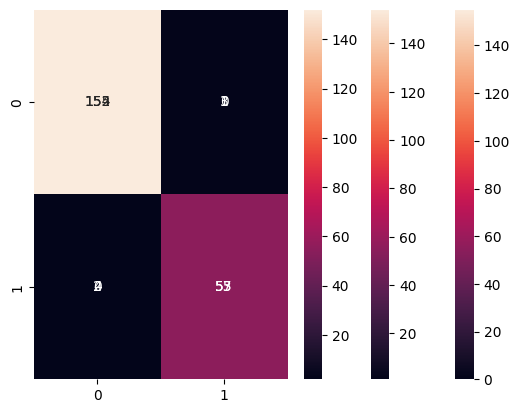

In [30]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')



rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')



xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')



results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision":[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1":[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results
results.to_csv("ml_results.csv")

# Deep Learning Model

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6910 - loss: 0.6050 - val_accuracy: 0.2847 - val_loss: 0.7199
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7656 - loss: 0.4759 - val_accuracy: 0.8333 - val_loss: 0.6221
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8628 - loss: 0.3694 - val_accuracy: 0.9375 - val_loss: 0.5035
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8941 - loss: 0.2965 - val_accuracy: 0.9653 - val_loss: 0.3879
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9115 - loss: 0.2420 - val_accuracy: 0.9931 - val_loss: 0.2817
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9097 - loss: 0.2145 - val_accuracy: 0.9931 - val_loss: 0.2155
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9392 - loss: 0.1811 - val_accuracy: 1.0000 - val_loss: 0.1600
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9392 - loss: 0.1590 - val_accuracy: 1.0000 - val_loss: 0.

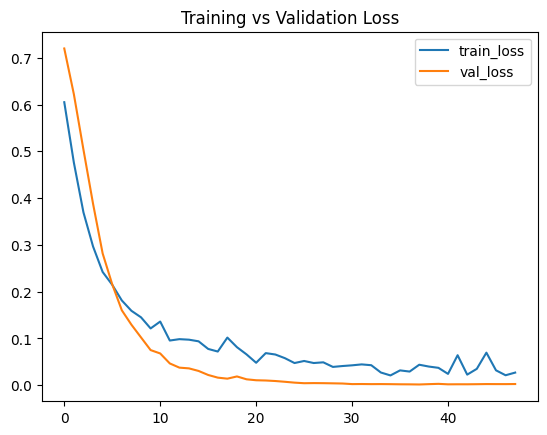

In [31]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# Input + First Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_dnn > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_dnn))
print("Precision:", precision_score(y_test, y_pred_dnn))
print("Recall:", recall_score(y_test, y_pred_dnn))
print("F1 Score:", f1_score(y_test, y_pred_dnn))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()



In [33]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost","DNN"],

    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_dnn)
    ],

    "Precision":[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_dnn)
    ],

    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_dnn)
    ],

    "F1":[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_dnn)
    ]
})

results
results.to_csv("model_results.csv", index=False)

# Hybrid Model

In [49]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

print(X_train_features.shape)


from xgboost import XGBClassifier

xgb_hybrid = XGBClassifier(random_state=42)

xgb_hybrid.fit(X_train_features, y_train)


y_pred_hybrid = xgb_hybrid.predict(X_test_features)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Hybrid Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print("Hybrid Precision:", precision_score(y_test, y_pred_hybrid))
print("Hybrid Recall:", recall_score(y_test, y_pred_hybrid))
print("Hybrid F1:", f1_score(y_test, y_pred_hybrid))

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "DNN": y_pred_dnn,
    "Hybrid": y_pred_hybrid
}

rows = []

for name, preds in models.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

results = pd.DataFrame(rows).round(4)
results

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
(720, 16)
Hybrid Accuracy: 0.9905660377358491
Hybrid Precision: 0.9824561403508771
Hybrid Recall: 0.9824561403508771
Hybrid F1: 0.9824561403508771


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9764,0.9815,0.9298,0.9550
2,XGBoost,0.9764,0.9483,0.9649,0.9565
3,DNN,0.9953,0.9828,1.0000,0.9913
4,Hybrid,0.9906,0.9825,0.9825,0.9825


# SHAP

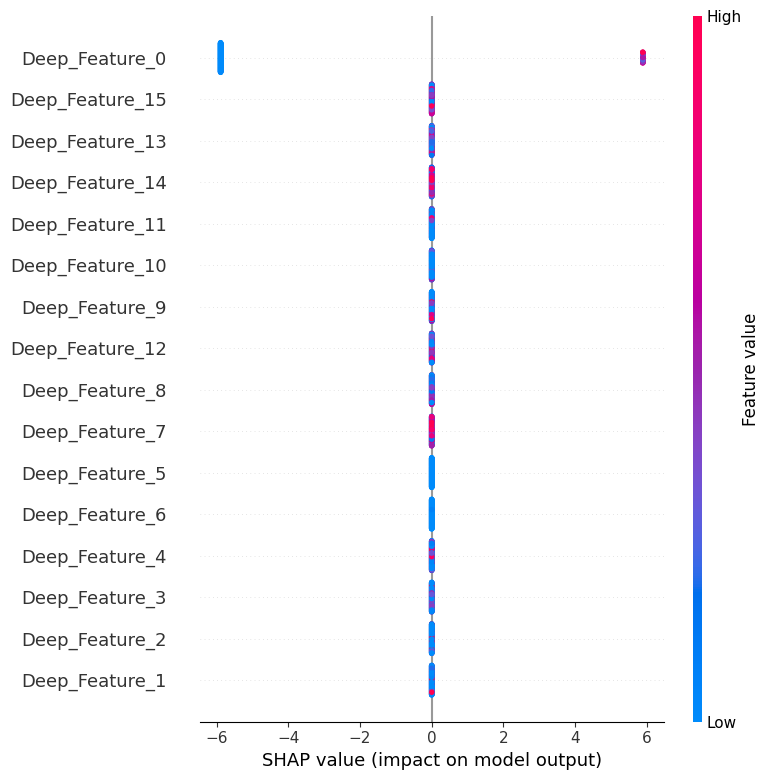

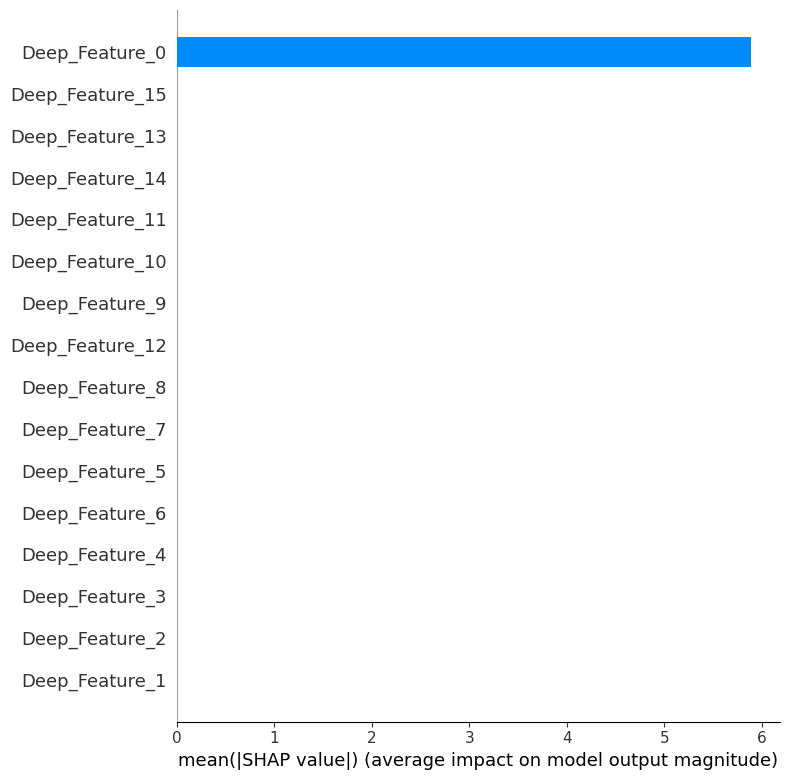

In [58]:
import shap
import pandas as pd

# Convert to DataFrame
feature_names = [f"Deep_Feature_{i}" for i in range(X_test_features.shape[1])]
X_test_df = pd.DataFrame(X_test_features, columns=feature_names)

# ✅ Correct explainer for XGBoost
explainer = shap.TreeExplainer(xgb_hybrid)

# Get SHAP values
shap_values = explainer.shap_values(X_test_df)

# Summary plot
shap.summary_plot(shap_values, X_test_df)

# Bar plot (IMPORTANT)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

In [66]:
!git config --global user.name "Yatharth Singh"
!git config --global user.email "yatharthsingh1508@gmail.com"

!git clone https://github.com/YatharthSingh05/asd-hybrid-ml-dl.git

%cd asd-hybrid-ml-dl

!ls /content

# =========================
# STEP 1 — Go to root
# =========================
%cd /content


# =========================
# STEP 2 — Delete old messy repo (if exists)
# =========================
!rm -rf asd-hybrid-ml-dl


# =========================
# STEP 3 — Clone fresh repo
# =========================
!git clone https://github.com/YatharthSingh05/asd-hybrid-ml-dl.git


# =========================
# STEP 4 — Enter repo folder
# =========================
%cd asd-hybrid-ml-dl


# =========================
# STEP 5 — Configure Git
# =========================
!git config --global user.name "Yatharth Singh"
!git config --global user.email "yatharthsingh1508@gmail.com"


# =========================
# STEP 6 — Copy ONLY required files from /content
# =========================
!cp /content/*.ipynb .
!cp /content/model_results.csv .
!cp /content/ml_results.csv .



# =========================
# STEP 8 — Check files
# =========================
!ls


# =========================
# STEP 9 — Add files to Git
# =========================
!git add .


# =========================
# STEP 10 — Commit
# =========================
!git commit -m "Added ASD Hybrid ML-DL Project"


# =========================
# STEP 11 — Push to GitHub
# =========================
!git push https://<YOUR_TOKEN>@github.com/your-username/asd-hybrid-ml-dl.git

Cloning into 'asd-hybrid-ml-dl'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/asd-hybrid-ml-dl/asd-hybrid-ml-dl/asd-hybrid-ml-dl/asd-hybrid-ml-dl/asd-hybrid-ml-dl
 asd-hybrid-ml-dl	     autism_screening.csv   sample_data   y_test.npy
'autism_screening (1).csv'   ml_results.csv	    X_test.npy	  y_train.npy
'autism_screening (2).csv'   model_results.csv	    X_train.npy
/content
Cloning into 'asd-hybrid-ml-dl'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/asd-hybrid-ml-dl
cp: cannot stat '/content/*.ipynb': No such file or directory
ml_results.csv	model_results.csv  README.md
[main 36c2669] A